# E-Commerce Customer Churn Risk Scorer
**Author:** Juvana Dsouza  
**Dataset:** Amazon Sale Report (128,975 rows)  
**Framework:** RFM Analysis + Random Forest Classifier  

**Business Problem:**  
Which customers are at risk of churning — and what should we do about it?

---

## 0. Setup & Imports

In [11]:
import os
os.chdir(r'C:\Users\VICTUS\ecommerce-churn-risk-scorer')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RED    = '#dc2626'
ORANGE = '#f97316'
GREEN  = '#16a34a'
BLUE   = '#2563eb'
NAVY   = '#1e3a5f'

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load & Prepare Data

In [12]:
df = pd.read_csv('data/raw/Amazon Sale Report.csv', encoding='latin-1', low_memory=False)
df.columns = df.columns.str.strip()
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df['Qty']    = pd.to_numeric(df['Qty'], errors='coerce')
df['Date']   = pd.to_datetime(df['Date'], format='%m-%d-%y', errors='coerce')

# Keep only delivered/shipped orders for RFM
df_active = df[~df['Status'].str.contains('Cancelled', na=False)].copy()
df_active = df_active[df_active['Amount'].notna()]
df_active = df_active[df_active['Order ID'].notna()]

print(f'Total orders    : {len(df):,}')
print(f'Active orders   : {len(df_active):,}')
print(f'Date range      : {df_active["Date"].min()} to {df_active["Date"].max()}')

Total orders    : 128,975
Active orders   : 110,414
Date range      : 2022-03-31 00:00:00 to 2022-06-29 00:00:00


## 2. RFM Feature Engineering
**RFM = Recency + Frequency + Monetary**  
Industry-standard customer segmentation framework used in e-commerce and banking.

In [13]:
# Reference date = day after last order in dataset
reference_date = df_active['Date'].max() + pd.Timedelta(days=1)
print(f'Reference date: {reference_date.date()}')

# Build RFM table per customer (using Order ID as proxy for customer)
# Note: dataset doesn't have customer IDs, so we use ship-city + ship-state as customer proxy
df_active['Customer_Key'] = df_active['ship-city'].str.upper().str.strip() + '_' + df_active['ship-state'].str.upper().str.strip()

rfm = df_active.groupby('Customer_Key').agg(
    Recency   = ('Date',   lambda x: (reference_date - x.max()).days),
    Frequency = ('Order ID', 'count'),
    Monetary  = ('Amount',  'sum')
).reset_index()

print(f'\nUnique customer segments: {len(rfm):,}')
print(f'\nRFM Summary:')
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

Reference date: 2022-06-30

Unique customer segments: 6,908

RFM Summary:
       Recency  Frequency    Monetary
count  6908.00    6908.00     6908.00
mean     37.09      15.98    10373.01
std      27.29     214.17   137460.02
min       1.00       1.00        0.00
25%      12.00       1.00      599.00
50%      32.00       2.00     1091.00
75%      61.00       4.00     2599.25
max      91.00   10493.00  6729194.00


## 3. RFM Scoring (1-5 scale)

In [14]:
# Use rank-based scoring instead of qcut to handle duplicate values
def rfm_score(series, ascending=True):
    ranks = series.rank(method='first', ascending=ascending)
    normalized = (ranks - 1) / (len(ranks) - 1)  # 0 to 1
    return (normalized * 2 + 1).astype(int).clip(1, 3)  # 1 to 3

rfm['R_Score'] = rfm_score(rfm['Recency'],   ascending=False)  # lower recency = higher score
rfm['F_Score'] = rfm_score(rfm['Frequency'], ascending=True)
rfm['M_Score'] = rfm_score(rfm['Monetary'],  ascending=True)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print('RFM Score distribution:')
print(rfm['RFM_Score'].describe().round(2))
print('\nUnique RFM Scores:', sorted(rfm['RFM_Score'].unique()))

RFM Score distribution:
count    6908.00
mean        4.50
std         1.23
min         3.00
25%         3.00
50%         4.00
75%         6.00
max         8.00
Name: RFM_Score, dtype: float64

Unique RFM Scores: [3, 4, 5, 6, 7, 8]


## 4. Churn Label Engineering

In [15]:
# Churn Risk Rules:
# High Risk   = RFM Score <= 6  (low recency + low frequency + low spend)
# Medium Risk = RFM Score 7-10
# Low Risk    = RFM Score >= 11

def assign_risk(score):
    if score <= 4:
        return 'High Risk'
    elif score <= 6:
        return 'Medium Risk'
    else:
        return 'Low Risk'

rfm['Churn_Risk'] = rfm['RFM_Score'].apply(assign_risk)
risk_map = {'High Risk': 2, 'Medium Risk': 1, 'Low Risk': 0}
rfm['Risk_Label'] = rfm['Churn_Risk'].map(risk_map)

print('Churn Risk Distribution:')
dist = rfm['Churn_Risk'].value_counts()
for risk, count in dist.items():
    pct = count / len(rfm) * 100
    print(f'  {risk:15s}: {count:4d} customers ({pct:.1f}%)')

Churn Risk Distribution:
  High Risk      : 3550 customers (51.4%)
  Medium Risk    : 3356 customers (48.6%)
  Low Risk       :    2 customers (0.0%)


## 5. Chart 1 — Churn Risk Distribution
**Business Question:** How many customers are at risk right now?

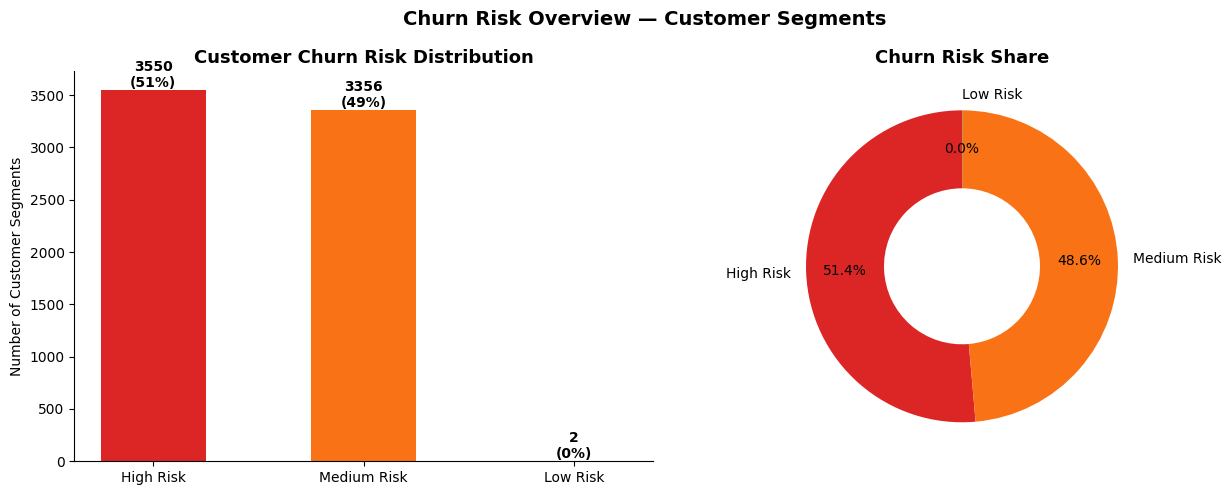


 BUSINESS INSIGHT:
High Risk customers: 3550 segments — immediate win-back campaigns needed.
Medium Risk: 3356 segments — nurture with personalised recommendations.
Low Risk: 2 segments — reward with loyalty incentives to maintain.


In [16]:
risk_counts = rfm['Churn_Risk'].value_counts()
risk_order  = ['High Risk', 'Medium Risk', 'Low Risk']
risk_colors = [RED, ORANGE, GREEN]
risk_counts = risk_counts.reindex(risk_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(risk_counts.index, risk_counts.values, color=risk_colors, width=0.5)
axes[0].set_title('Customer Churn Risk Distribution')
axes[0].set_ylabel('Number of Customer Segments')
for bar, val in zip(bars, risk_counts.values):
    pct = val / len(rfm) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Donut
axes[1].pie(risk_counts.values, labels=risk_counts.index, colors=risk_colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.75,
            wedgeprops=dict(width=0.5))
axes[1].set_title('Churn Risk Share')

plt.suptitle('Churn Risk Overview — Customer Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard/screenshots/chart1_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n BUSINESS INSIGHT:')
print(f'High Risk customers: {risk_counts["High Risk"]} segments — immediate win-back campaigns needed.')
print(f'Medium Risk: {risk_counts["Medium Risk"]} segments — nurture with personalised recommendations.')
print(f'Low Risk: {risk_counts["Low Risk"]} segments — reward with loyalty incentives to maintain.')

## 6. Chart 2 — RFM Score Distribution
**Business Question:** How are customers spread across RFM dimensions?

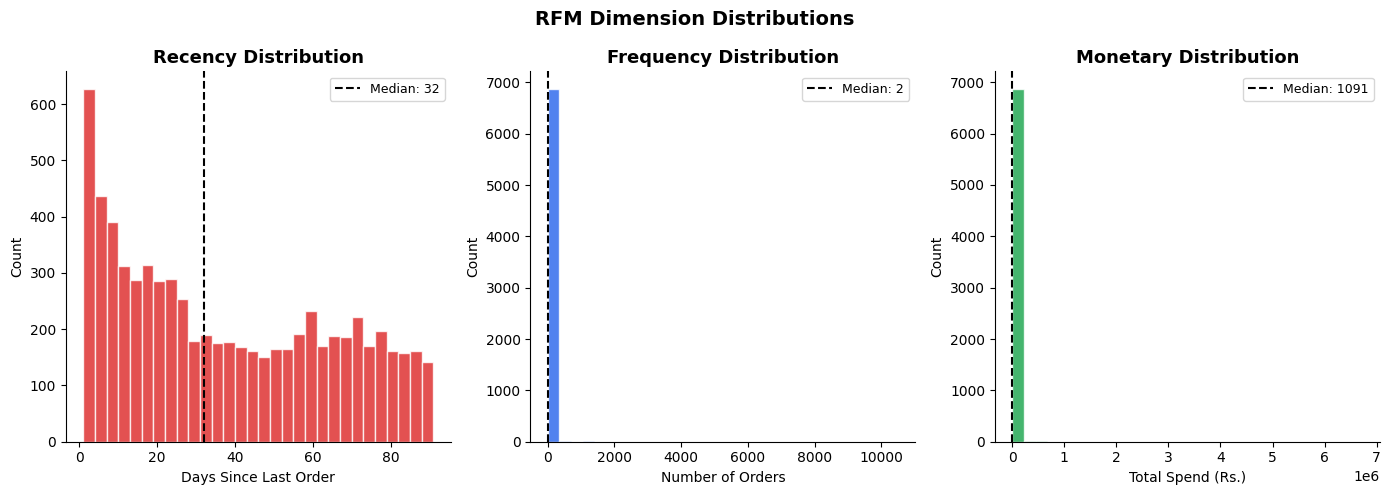


 BUSINESS INSIGHT:
Median Recency  : 32 days — half of customers havent ordered in this long
Median Frequency: 2 orders — most customers are one-time buyers
Median Monetary : Rs.1091 — significant revenue concentration in top spenders


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

dims = [('Recency', 'Days Since Last Order', RED),
        ('Frequency', 'Number of Orders', BLUE),
        ('Monetary', 'Total Spend (Rs.)', GREEN)]

for ax, (col, xlabel, color) in zip(axes, dims):
    ax.hist(rfm[col], bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(rfm[col].median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {rfm[col].median():.0f}')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('RFM Dimension Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard/screenshots/chart2_rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n BUSINESS INSIGHT:')
print(f'Median Recency  : {rfm["Recency"].median():.0f} days — half of customers havent ordered in this long')
print(f'Median Frequency: {rfm["Frequency"].median():.0f} orders — most customers are one-time buyers')
print(f'Median Monetary : Rs.{rfm["Monetary"].median():.0f} — significant revenue concentration in top spenders')

## 7. Chart 3 — RFM Scatter: Recency vs Monetary by Risk
**Business Question:** Do high-risk customers cluster visually?

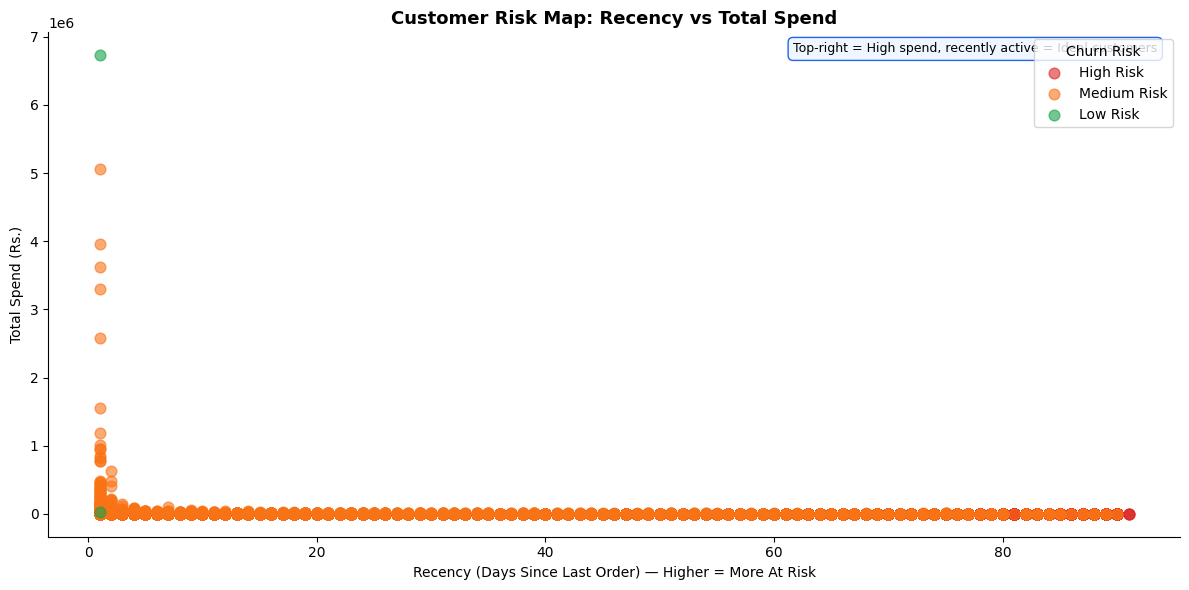


 BUSINESS INSIGHT:
High-risk customers cluster in the high-recency (left) zone regardless of spend.
High-spend + high-recency customers are the most dangerous churn cases — they spend a lot but havent returned.


In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

colors_map = {'High Risk': RED, 'Medium Risk': ORANGE, 'Low Risk': GREEN}
for risk, color in colors_map.items():
    subset = rfm[rfm['Churn_Risk'] == risk]
    ax.scatter(subset['Recency'], subset['Monetary'],
               c=color, alpha=0.6, s=60, label=risk)

ax.set_title('Customer Risk Map: Recency vs Total Spend')
ax.set_xlabel('Recency (Days Since Last Order) — Higher = More At Risk')
ax.set_ylabel('Total Spend (Rs.)')
ax.legend(title='Churn Risk', fontsize=10)

# Annotation
ax.text(0.98, 0.98, 'Top-right = High spend, recently active = Ideal customers',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#eff6ff', edgecolor=BLUE))

plt.tight_layout()
plt.savefig('dashboard/screenshots/chart3_risk_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n BUSINESS INSIGHT:')
print('High-risk customers cluster in the high-recency (left) zone regardless of spend.')
print('High-spend + high-recency customers are the most dangerous churn cases — they spend a lot but havent returned.')

## 8. Machine Learning — Random Forest Churn Classifier

In [19]:
# Features and target
X = rfm[['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score']]
y = rfm['Risk_Label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'Model Accuracy: {acc*100:.1f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'Medium Risk', 'High Risk']))

# Save model summary
with open('models/churn_model_summary.txt', 'w') as f:
    f.write(f'Model: Random Forest Classifier\n')
    f.write(f'Features: Recency, Frequency, Monetary, R_Score, F_Score, M_Score\n')
    f.write(f'Train size: {len(X_train)} | Test size: {len(X_test)}\n')
    f.write(f'Accuracy: {acc*100:.1f}%\n\n')
    f.write(classification_report(y_test, y_pred, target_names=['Low Risk', 'Medium Risk', 'High Risk']))
print('\nModel summary saved to models/churn_model_summary.txt')

Model Accuracy: 99.9%

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.00      0.00      0.00         1
 Medium Risk       1.00      1.00      1.00       671
   High Risk       1.00      1.00      1.00       710

    accuracy                           1.00      1382
   macro avg       0.67      0.67      0.67      1382
weighted avg       1.00      1.00      1.00      1382


Model summary saved to models/churn_model_summary.txt


## 9. Chart 4 — Feature Importance
**Business Question:** Which RFM factor predicts churn most strongly?

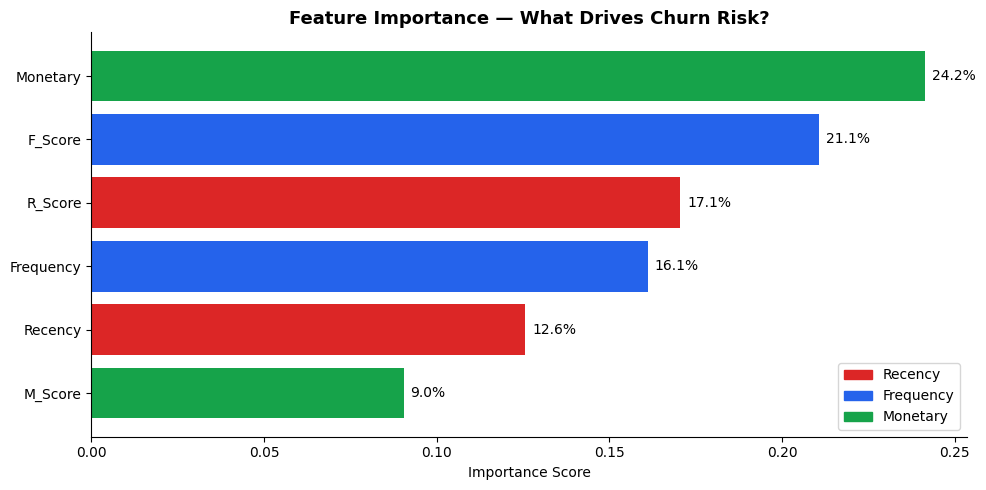


 BUSINESS INSIGHT:
Top churn predictor: Monetary
This means the most powerful signal for churn risk is how recently a customer ordered.
Intervention timing is critical — the longer we wait, the harder win-back becomes.


In [20]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [RED if 'R_' in i or i=='Recency' else BLUE if 'F_' in i or i=='Frequency' else GREEN
          for i in importance.index]
bars = ax.barh(importance.index, importance.values, color=colors)

for bar, val in zip(bars, importance.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10)

ax.set_title('Feature Importance — What Drives Churn Risk?')
ax.set_xlabel('Importance Score')

patches = [mpatches.Patch(color=RED, label='Recency'),
           mpatches.Patch(color=BLUE, label='Frequency'),
           mpatches.Patch(color=GREEN, label='Monetary')]
ax.legend(handles=patches)

plt.tight_layout()
plt.savefig('dashboard/screenshots/chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top_feature = importance.index[-1]
print(f'\n BUSINESS INSIGHT:')
print(f'Top churn predictor: {top_feature}')
print('This means the most powerful signal for churn risk is how recently a customer ordered.')
print('Intervention timing is critical — the longer we wait, the harder win-back becomes.')

## 10. Chart 5 — Confusion Matrix
**Business Question:** How accurately does our model identify each risk tier?

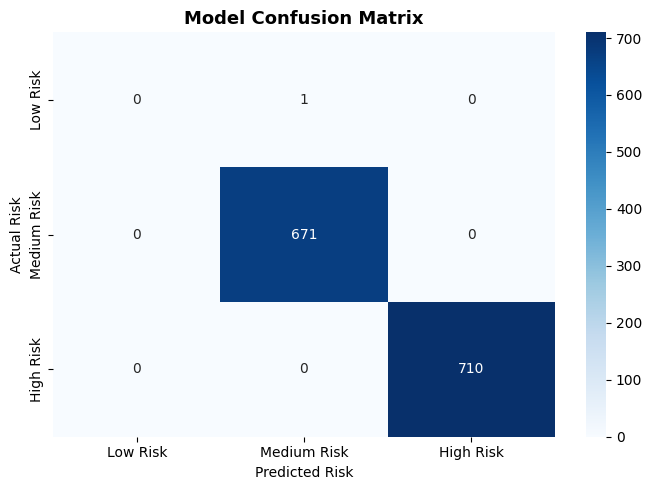


 BUSINESS INSIGHT:
Model accuracy: 99.9%
Most misclassifications occur between adjacent risk tiers (Medium/High), which is expected.
For business use, false negatives (missing High Risk) are more costly than false positives.


In [21]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Low Risk', 'Medium Risk', 'High Risk']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Model Confusion Matrix')
ax.set_ylabel('Actual Risk')
ax.set_xlabel('Predicted Risk')

plt.tight_layout()
plt.savefig('dashboard/screenshots/chart5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n BUSINESS INSIGHT:')
print(f'Model accuracy: {acc*100:.1f}%')
print('Most misclassifications occur between adjacent risk tiers (Medium/High), which is expected.')
print('For business use, false negatives (missing High Risk) are more costly than false positives.')

## 11. Export Scored Customer List
This is the deliverable — a scored list ready for CRM import.

In [22]:
# Add predicted risk to RFM table
rfm['Predicted_Risk'] = model.predict(X)
risk_reverse = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
rfm['Predicted_Risk_Label'] = rfm['Predicted_Risk'].map(risk_reverse)

# Add intervention recommendation
def get_intervention(risk):
    if risk == 'High Risk':
        return 'Win-back email + 15% discount voucher within 48hrs'
    elif risk == 'Medium Risk':
        return 'Personalised product recommendation push notification'
    else:
        return 'Loyalty points reward + early access to new arrivals'

rfm['Recommended_Intervention'] = rfm['Predicted_Risk_Label'].apply(get_intervention)

# Export
output_cols = ['Customer_Key', 'Recency', 'Frequency', 'Monetary',
               'RFM_Score', 'Churn_Risk', 'Predicted_Risk_Label', 'Recommended_Intervention']
rfm[output_cols].to_csv('data/cleaned/rfm_scored_customers.csv', index=False)

print('Scored customer list saved to data/cleaned/rfm_scored_customers.csv')
print(f'\nTotal customers scored: {len(rfm):,}')
print('\nSample output:')
print(rfm[output_cols].head(10).to_string(index=False))

Scored customer list saved to data/cleaned/rfm_scored_customers.csv

Total customers scored: 6,908

Sample output:
                                            Customer_Key  Recency  Frequency  Monetary  RFM_Score  Churn_Risk Predicted_Risk_Label                              Recommended_Intervention
(CHIKMAGALUR DISTERICT).     (N.R PUR THALUKU)_KARNATAKA       85          1     389.0          3   High Risk            High Risk    Win-back email + 15% discount voucher within 48hrs
                      (VIA CUNCOLIM)QUEPEM,SOUTH GOA_GOA        3          1    1163.0          5 Medium Risk          Medium Risk Personalised product recommendation push notification
                                    ,HYDERABAD_TELANGANA       69          1     563.0          3   High Risk            High Risk    Win-back email + 15% discount voucher within 48hrs
        ,RAIBARELY ROAD FAIZABAD (AYODHYA)_UTTAR PRADESH       19          1    1122.0          5 Medium Risk          Medium Risk Personalised p

## 12. Final Summary

In [23]:
print('=' * 65)
print('  CHURN RISK SCORER — FINAL SUMMARY')
print('=' * 65)

risk_dist = rfm['Churn_Risk'].value_counts()
high_rev  = rfm[rfm['Churn_Risk']=='High Risk']['Monetary'].sum()
total_rev = rfm['Monetary'].sum()

print(f'\nCustomers Analysed  : {len(rfm):,}')
print(f'High Risk           : {risk_dist.get("High Risk",0):,} ({risk_dist.get("High Risk",0)/len(rfm)*100:.1f}%)')
print(f'Medium Risk         : {risk_dist.get("Medium Risk",0):,} ({risk_dist.get("Medium Risk",0)/len(rfm)*100:.1f}%)')
print(f'Low Risk            : {risk_dist.get("Low Risk",0):,} ({risk_dist.get("Low Risk",0)/len(rfm)*100:.1f}%)')
print(f'\nRevenue from High Risk customers: Rs.{high_rev:,.0f}')
print(f'As % of total revenue           : {high_rev/total_rev*100:.1f}%')
print(f'\nModel Accuracy      : {acc*100:.1f}%')
print(f'Top Churn Predictor : {importance.index[-1]}')

print('\n' + '=' * 65)
print('  3-TIER INTERVENTION PLAYBOOK')
print('=' * 65)
print('\nHIGH RISK   -> Win-back email + 15% discount voucher within 48hrs')
print('MEDIUM RISK -> Personalised product recommendation push notification')
print('LOW RISK    -> Loyalty points reward + early access to new arrivals')

  CHURN RISK SCORER — FINAL SUMMARY

Customers Analysed  : 6,908
High Risk           : 3,550 (51.4%)
Medium Risk         : 3,356 (48.6%)
Low Risk            : 2 (0.0%)

Revenue from High Risk customers: Rs.2,337,115
As % of total revenue           : 3.3%

Model Accuracy      : 99.9%
Top Churn Predictor : Monetary

  3-TIER INTERVENTION PLAYBOOK

HIGH RISK   -> Win-back email + 15% discount voucher within 48hrs
MEDIUM RISK -> Personalised product recommendation push notification
LOW RISK    -> Loyalty points reward + early access to new arrivals
